In [9]:
from itertools import product as prdt
"""
Input: A graph X, a finite group G and a voltage assignment function alpha.
Output: The voltage cover Y = X(G, alpha).
"""
def voltage_cover(X, G, alpha): # alpha is a function.
    X_edges = list(X.edges())
    X_verts = list(X.vertices())
    Y = DiGraph(loops=True, multiedges=True)
    Y_verts = list(prdt(X_verts, G.list())) # Cartesian product X_verts × G
    X_cross_G = list(prdt(X_edges, G.list()))

    Y_edges = []
    for (e, g) in X_cross_G: 
        u, v, label = e
        tail = (u, g)
        head = (v, g+alpha(e))
        Y_edges.append((tail, head, label))
    
    Y.add_vertices(Y_verts)
    Y.add_edges(Y_edges)
    return Y
    # Y.show(layout='spring',
    #     vertex_labels=True,
    #     figsize=(10, 10),       
    #     vertex_size=250,         
    #     edge_thickness=2)

In [10]:
from collections import defaultdict

'''
    Input: A (unoriented/undirected) graph g.
    Output: The line oriented graph induced by g.
'''
def line_orient_graph(g):
    UO_g_edges = list(g.edges())
    UO_g_edges = [(o,t, "f", 0) for o,t,l in UO_g_edges]
    g_edges = list.copy(UO_g_edges)
    """
    NOTE: 'o' is the origin, 't' is the terminus, 'd' is the direction assigning a vertex and its inverse (This is called an "orientation" in some 
        papers) and 'l' is the label. Edges and their inverse share a label.
    """
    curr_counts = defaultdict(int)
    result = []
    for (o,t,d,l) in UO_g_edges: 
        n = curr_counts[(o, t, d, l)]
        result.append((o, t, d, n))
        curr_counts[(o, t, d, l)] += 1

    g_edges = result
    rev_edges = [(t, o, "b", l) for o,t,d,l in g_edges]
    g_edges += rev_edges

    LO_g = dict()
    for o,t,d,l in g_edges:
        LO_g.setdefault((o, t, d, l), {})

    cnt = 0
    for (o1,t1,d1,l1), adj_es in LO_g.items():
        for o2,t2,d2,l2 in g_edges:
            # This is saying if the two edges dont share an origin and terminus, or if these edges are the same in every respect but a change in 
            # direction (i.e., they are inverses).
            if t1 != o2 or (o2 == t1 and t2 == o1 and l2 == l1 and d1 != d2): 
                continue
            else:
                adj_es.setdefault((o2, t2, d2, l2),f"{cnt}")
                cnt = cnt + 1

    return DiGraph(LO_g, loops = True)

In [11]:
"""
Inputs: A prime p, n ∈ ℤ^+.
Outputs: The minus class number of ℚ(ζ_p^n).
"""
def cyclotomic_minus_class_number(p,n):
    DC_G = DirichletGroup(p^n)
    odd_DCharacters = [chi for chi in DC_G.list() if chi(p^n-1) == -1]
    B_prod = prod([(-1/2)*chi.bernoulli(1) for chi in odd_DCharacters])
    return 2*p^n*B_prod

"""
    NOTE: Maximum values for reasonable runtimes.
    p       n
    3       5
    5       4
    7       3
    11      2
"""

'\n    NOTE: Maximum values for reasonable runtimes.\n    p       n\n    3       5\n    5       4\n    7       3\n    11      2\n'

<>:42: DeprecationWarning: invalid escape sequence '\ '
<>:42: DeprecationWarning: invalid escape sequence '\ '
/tmp/ipykernel_406828/60257418.py:42: DeprecationWarning: invalid escape sequence '\ '
  """


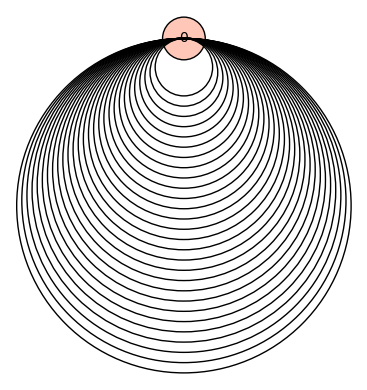

Number of edeges in X == 28


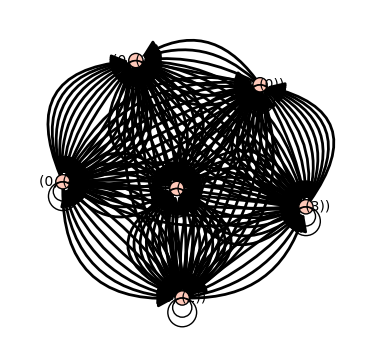

{'p': 3, 'n': 2, 'BF_TOR_ORD': 3^6, 'minus class number': 1}


In [12]:
# import pickle
"""
    Input: A prime p and it must be odd if n == 1, n ∈ ℤ^+.
    Output: A dictionary containing values: p, n, #BF(Y)_tor and the minus class number of ℚ(ζ_p^n). 
"""
def BF_minus_class_group_conjecture(p,n):
    X = DiGraph(loops=True, multiedges=True)
    X.add_edge(0, 0, (0, 0)) 
    
    for i in range(1, p**n + 1):        
        for j in range(1, i + 1):
            if i % p != 0:      
                X.add_edge(0, 0, (i, j))
    
    X.show()
    print(f"Number of edeges in X == {len(X.edges())}")
    """
        NOTE: We use the additive abelian group ℤ/φ(p^n)ℤ as opposed to the multiplicative group 
        (ℤ/p^nℤ)^× ≅ Gal(ℚ(ζ_p^n/ℚ)),for practical reasons, the function sigma(i) below is meant 
        to represent the (unique) preimage of σ_i ∈ Gal(ℚ(ζ_p^n/ℚ)) under the isomorphism. 

        The choice of the bouqet graph and this specific voltage assignement is related to the 
        stickelberger element θ = -1/(p^n)∑_{1 ≤ i ≤ p^n, gcd(i, p) == 1} iσ_i ∈ ℚ[DELTA] (== The ℚ-group algebra over DELTA)
    """
    DELTA = AdditiveAbelianGroup([euler_phi(p**n)]) # euler_phi == φ
    gen = DELTA.gen(0) # ord(gen) == |DELTA|
    zeta_p = primitive_root(p**n) # (zeta_p)^(p-1) ≡ 1 (mod p^n)
    """
        Input: An i ∈ ℤ.
        Output: k*gen, such that (zeta_p)^k ≡ i (mod p^n), ie, sigma is the isomorphism (ℤ/p^nℤ)^× ⟶ ℤ/φ(p^n)ℤ.
    """

    def sigma(i):
        if i == 0:
            return DELTA.zero()
        
        k = discrete_log(Mod(i, p**n), Mod(zeta_p, p**n))
        return k * gen
    
    pre_comp_sigmas = {i:sigma(i) for i in range(1, p**n+1) if i % p != 0}

    """
        Input: An edge e = (origin, terminus, label == (i,j)), (i,j), following the labelling seen in  [L.V.M. p.g. 24].
        Output: -sigma(i). This ensures that the p^nθ = 1 - ∑_{e ∈ E_X \ e_0} α(e), θ as above.
    """
    def alpha(e):
        label = e[2]              
        i = label[0]
        if i == 0:
            return pre_comp_sigmas[1]        
        else:
            return -pre_comp_sigmas[i]        

    Y = voltage_cover(X, DELTA, alpha)
    Y.show()
    BFO = identity_matrix(Y.order()) - Y.adjacency_matrix() # The Bowen-Franks (BF) operator of Y.
    BF_SNF, non_var, non_var1 = BFO.smith_form() # The Smith normal form (SNF) of the BF operator of Y.

    # Computes the order of the torsion part of the BF group, ie, the product of the nonzero entries in the SNF of the BF operator.
    BF_TOR_ORD = prod([entry for entry in BF_SNF.diagonal() if entry != 0]) 

    return {'p': p, 'n': n, 'BF_TOR_ORD': factor(BF_TOR_ORD), 'minus class number': cyclotomic_minus_class_number(p,n)}

print(BF_minus_class_group_conjecture(3,2))
# three_data = []
# for n in range(1, 10):
#     three_data.append(BF_minus_class_group_conjecture(3,n))

# with open('three_data.pkl', 'wb') as file:
#     pickle.dump(three_data, file)
    
# two_data = []
# for n in range(1, 10):
#     two_data.append(BF_minus_class_group_conjecture(2,n))

# with open('two_data.pkl', 'wb') as file:
#     pickle.dump(two_data, file)

In [13]:
from collections import defaultdict
'''
    Input: A (unoriented/undirected) graph g.
    Output: The line oriented graph induced by g.
'''
def line_orient_graph(g):
    UO_g_edges = list(g.edges())
    UO_g_edges = [(o,t, "f", 0) for o,t,l in UO_g_edges]
    g_edges = list.copy(UO_g_edges)

    curr_counts = defaultdict(int)
    result = []
    for (o,t,d,l) in UO_g_edges:
        n = curr_counts[(o, t, d, l)]
        result.append((o, t, d, n))
        curr_counts[(o, t, d, l)] += 1
    g_edges = result
    rev_edges = [(t, o, "b", l) for o,t,d,l in g_edges]
    g_edges += rev_edges

    LO_g = dict()
    for o,t,d,l in g_edges:
        LO_g.setdefault((o, t, d, l), {})

    cnt = 0
    for (o1,t1,d1,l1), adj_es in LO_g.items():
        for o2,t2,d2,l2 in g_edges:
            if t1 != o2 or (o2 == t1 and t2 == o1 and l2 == l1 and d1 != d2): 
                continue
            else:
                adj_es.setdefault((o2, t2, d2, l2),f"{cnt}")
                cnt = cnt + 1

    return DiGraph(LO_g, loops = True)